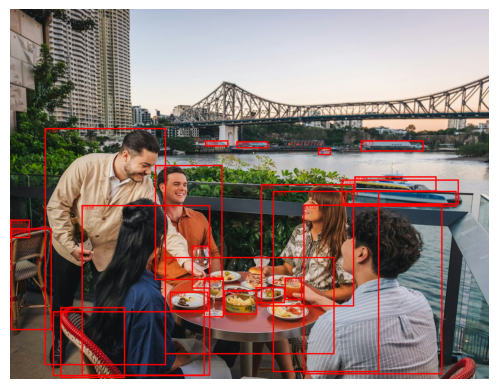

In [ ]:
# Implementing a computer vision project, such as object detection or image segmentation.
import torch, torchvision
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import torchvision.transforms as T
import requests
from io import BytesIO

# 1. Download a sample image
url = "https://images.unsplash.com/photo-1789758489734-acb071437efc?q=80&w=1052&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDF8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"  # sample image
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

# 2. Load pretrained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# 3. Transform image to tensor
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img)

# 4. Run object detection
with torch.no_grad():
    preds = model([img_tensor])[0]

# 5. Draw bounding boxes
draw = ImageDraw.Draw(img)
for box, score, label in zip(preds['boxes'], preds['scores'], preds['labels']):
    if score > 0.5:  # confidence threshold
        draw.rectangle(box.tolist(), outline="red", width=3)
        draw.text((box[0], box[1]), f"{label.item()}:{score:.2f}", fill="red")

# 6. Show result
plt.imshow(img)
plt.axis("off")
plt.show()
